# Breast Cancer CAD System — Master Notebook

End-to-end pipeline: **Preprocessing -> YOLO26n (detection) -> U-Net (segmentation) -> ResNet50 (classification)**.

Every cell below calls into the reusable modules under `preprocessing/`, `yolo/`, `unet/`, `resnet/`, `inference/` — no pipeline logic is duplicated here.

**Important:** the training cells (Stage 2/3/4) are provided fully ready-to-run but are **not meant to be executed automatically** (e.g. via "Run All") — training each stage takes substantial time and should be run deliberately, one stage at a time, on your own hardware/schedule.

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# config.yaml paths (dataset/, checkpoints/, results/, ...) are relative to the repo root,
# so run the kernel from there rather than from notebooks/.
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.config import load_config
from utils.seed import set_seed, get_device

config = load_config(str(REPO_ROOT / "config.yaml"))
# Uncomment to smoke-test the whole pipeline on a tiny subset before a real run:
# config = load_config(str(REPO_ROOT / "config.yaml"), overrides=str(REPO_ROOT / "configs/quick_run.yaml"))

set_seed(config["seed"], config["deterministic"])
device = get_device(config.get("device"))
print(f"Device: {device}")
print(f"Repo root: {REPO_ROOT}")


Device: mps
Repo root: /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection


## Stage 1 — Preprocessing & Augmentation

Validates every image/mask pair, builds a stratified 70/15/15 split (content-duplicate-aware — see the
`duplicate_image_cross_class` check in `preprocessing/validation.py`), derives per-lesion YOLO bounding
boxes from the masks, and renders sanity-check visualizations. No model training happens in this stage —
safe to re-run any time.

2026-10-07 11:23:40 | INFO     | preprocessing | Building manifest from raw BUSI_Jpeg directories...
2026-10-07 11:23:40 | INFO     | preprocessing | Found 647 images.
2026-10-07 11:23:40 | INFO     | preprocessing | Validating dataset (pairing, corruption, duplicates, dimensions, masks)...
2026-10-07 11:23:40 | INFO     | preprocessing | 0 critical issue(s), 1 warning(s).
2026-10-07 11:23:40 | WARNING  | preprocessing | [duplicate_image_cross_class] malignant (145): identical to benign (433) (benign)
2026-10-07 11:23:40 | INFO     | preprocessing | Splitting dataset (stratified 70/15/15, seed=42)...
2026-10-07 11:23:41 | INFO     | preprocessing | Split sizes: {'train': 452, 'val': 98, 'test': 97}
2026-10-07 11:23:41 | INFO     | preprocessing | Split class counts: {'train': {'benign': 306, 'malignant': 146}, 'val': {'benign': 65, 'malignant': 33}, 'test': {'benign': 66, 'malignant': 31}}
2026-10-07 11:23:41 | INFO     | preprocessing | Building per-lesion manifests...
2026-10-07 11:2

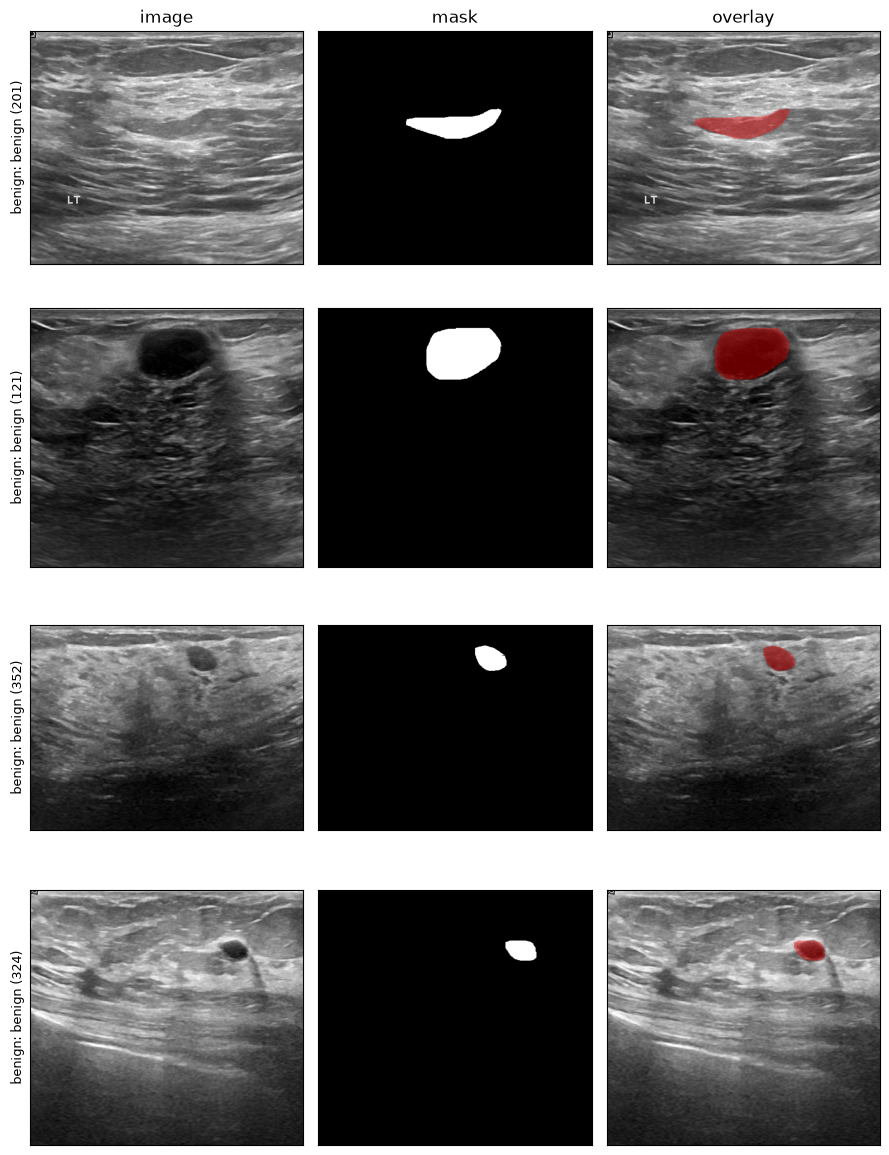

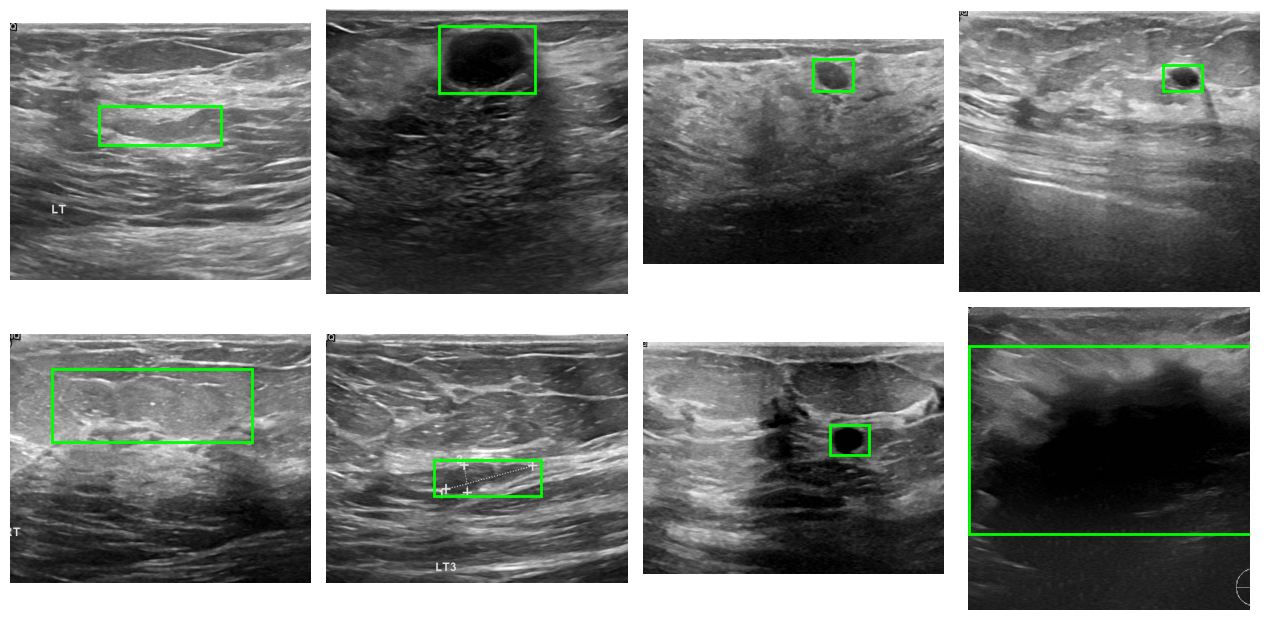

In [2]:
from preprocessing.pipeline import run_stage1

stage1_result = run_stage1(config)
print(stage1_result["report"])


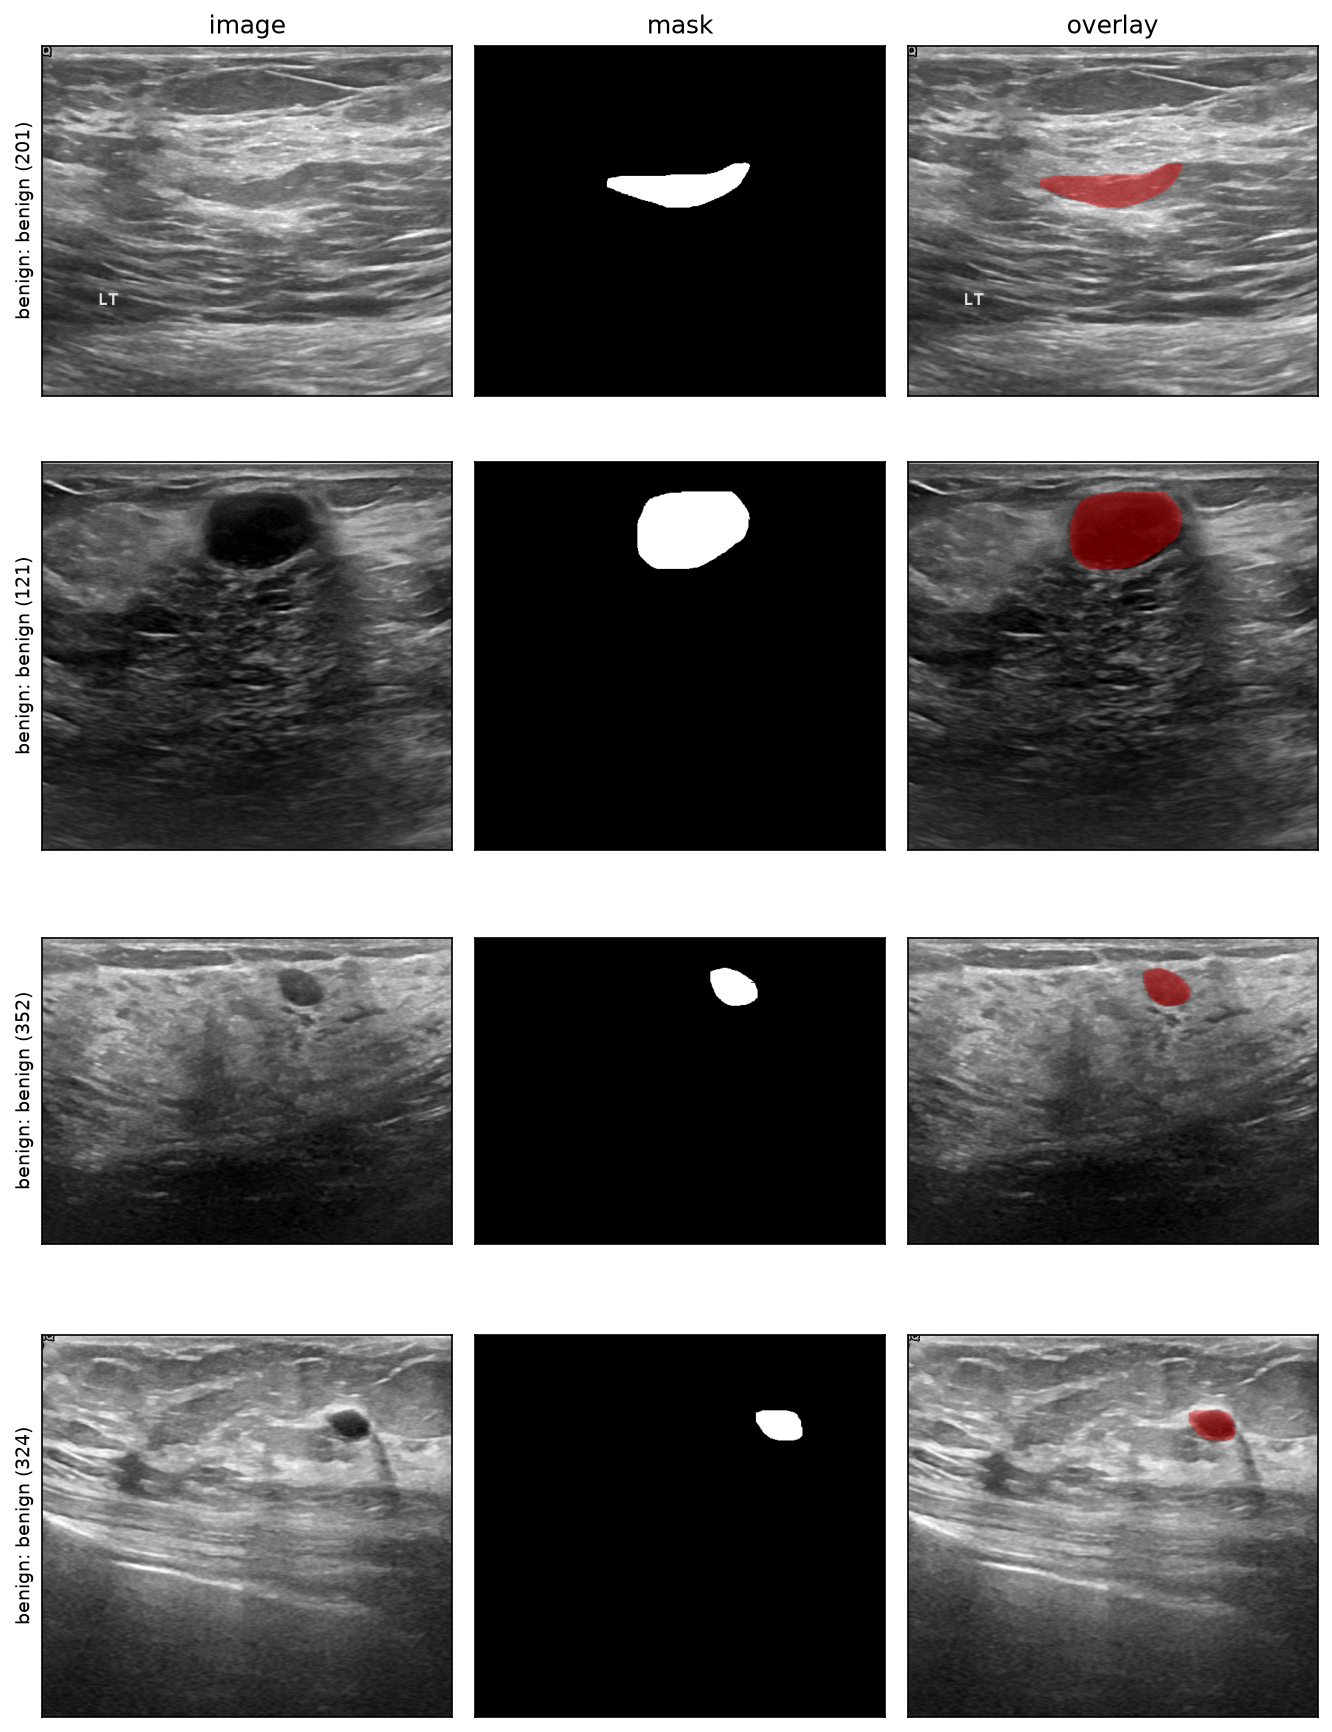

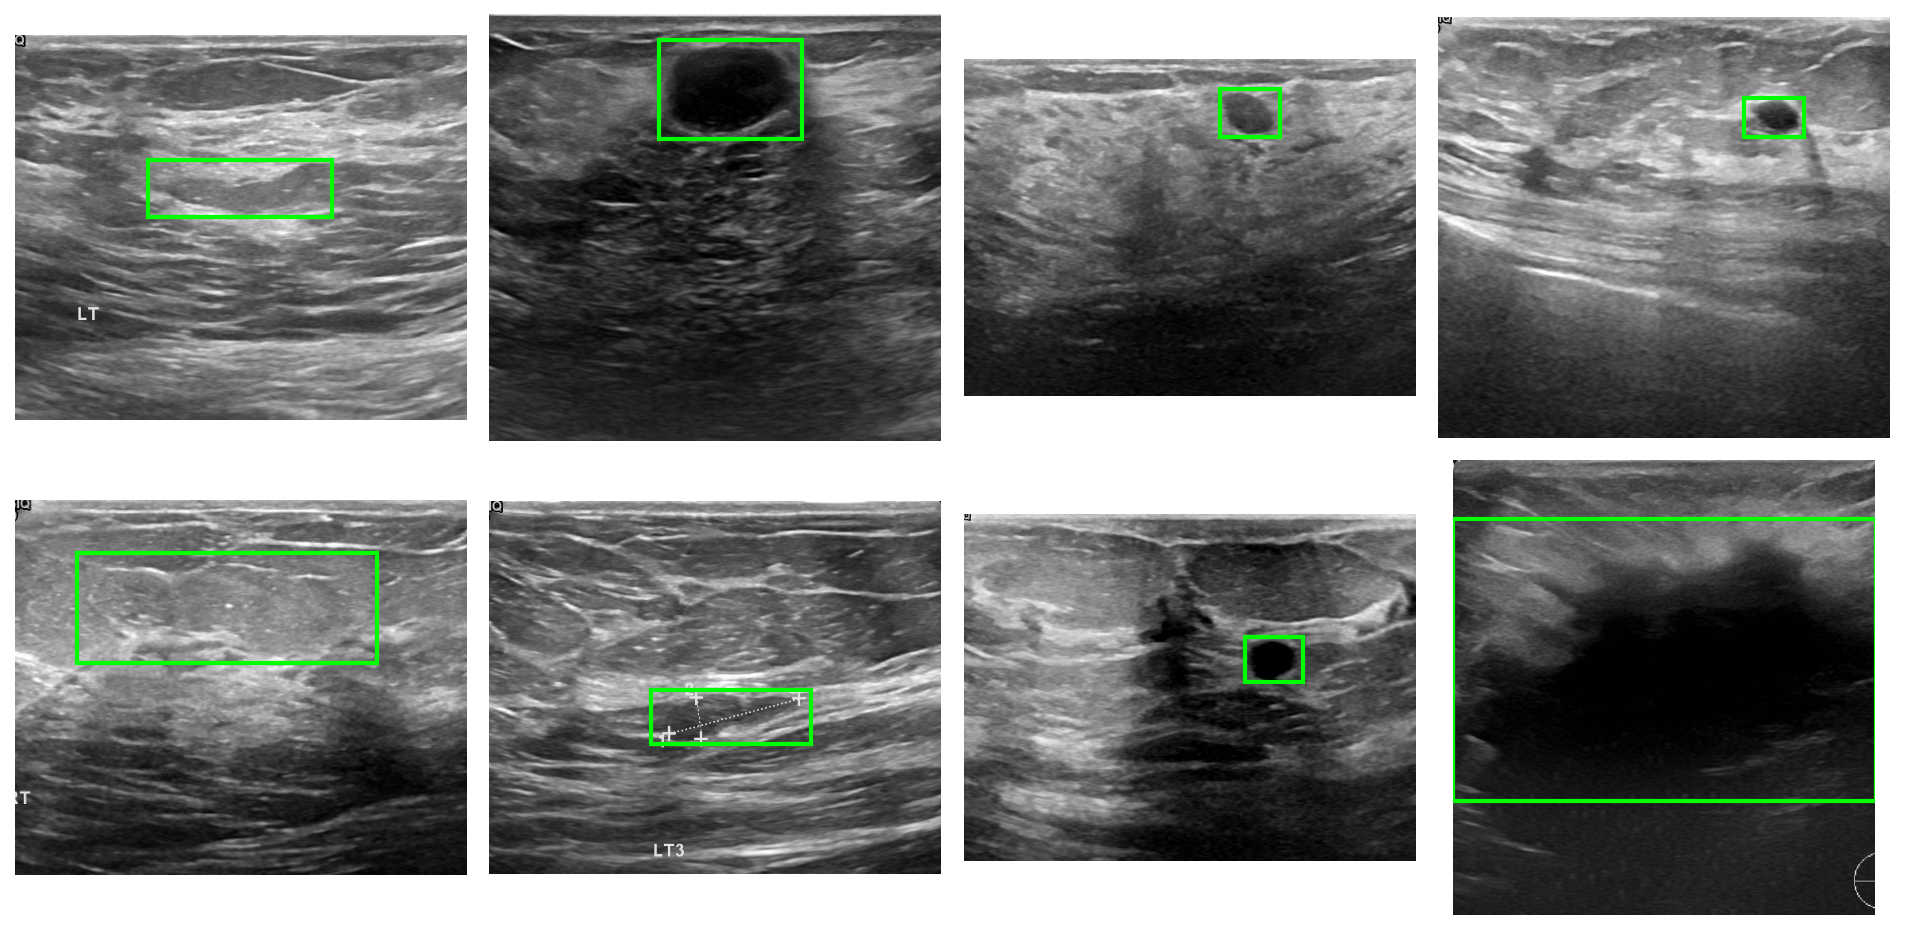

In [3]:
from IPython.display import Image as IPImage, display

results_dir = REPO_ROOT / config["paths"]["results"] / "preprocessing"
display(IPImage(filename=str(results_dir / "mask_sanity_check.png")))
display(IPImage(filename=str(results_dir / "bbox_overlay_check.png")))


YOLO-stage augmentations (full safe + cautious set):
U-Net-stage augmentations (safe + cautious + tiny elastic):
ResNet-stage augmentations (conservative safe set only):


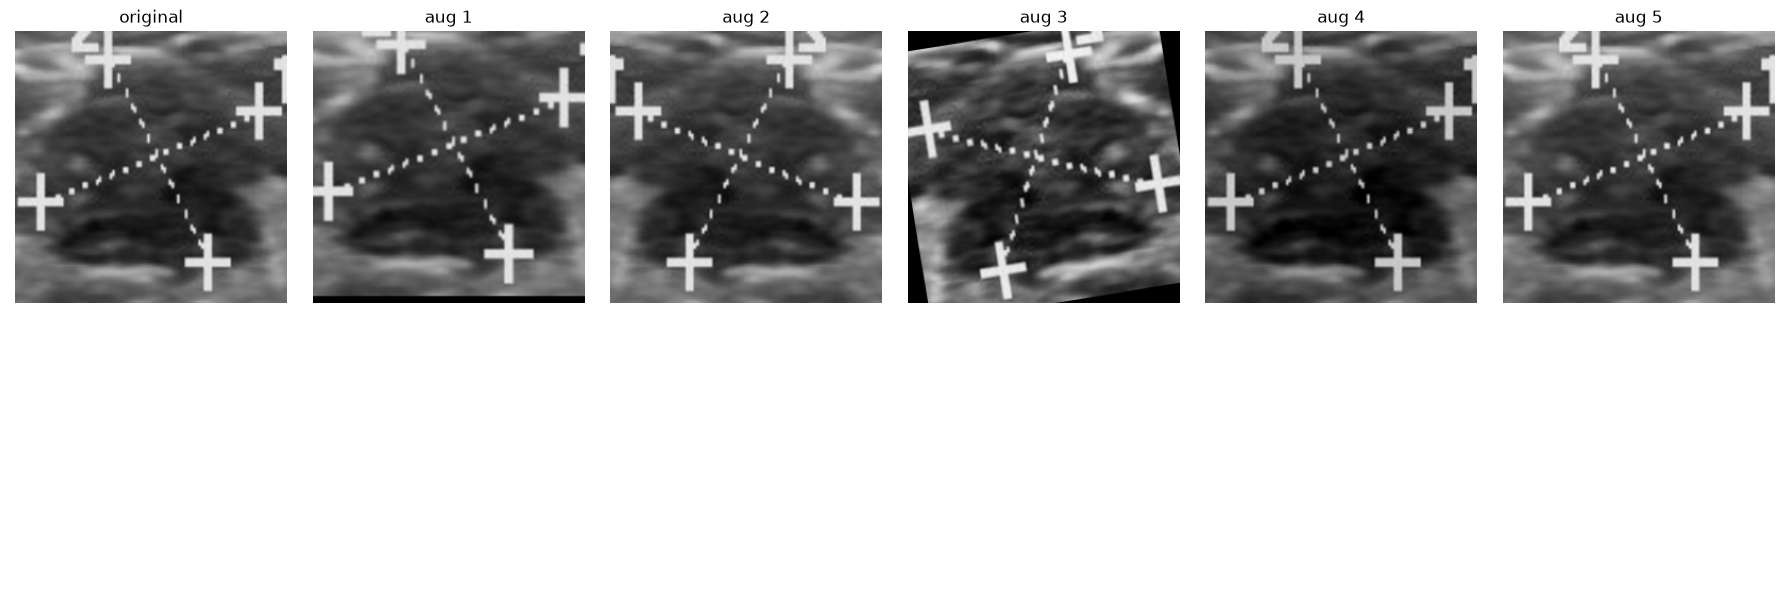

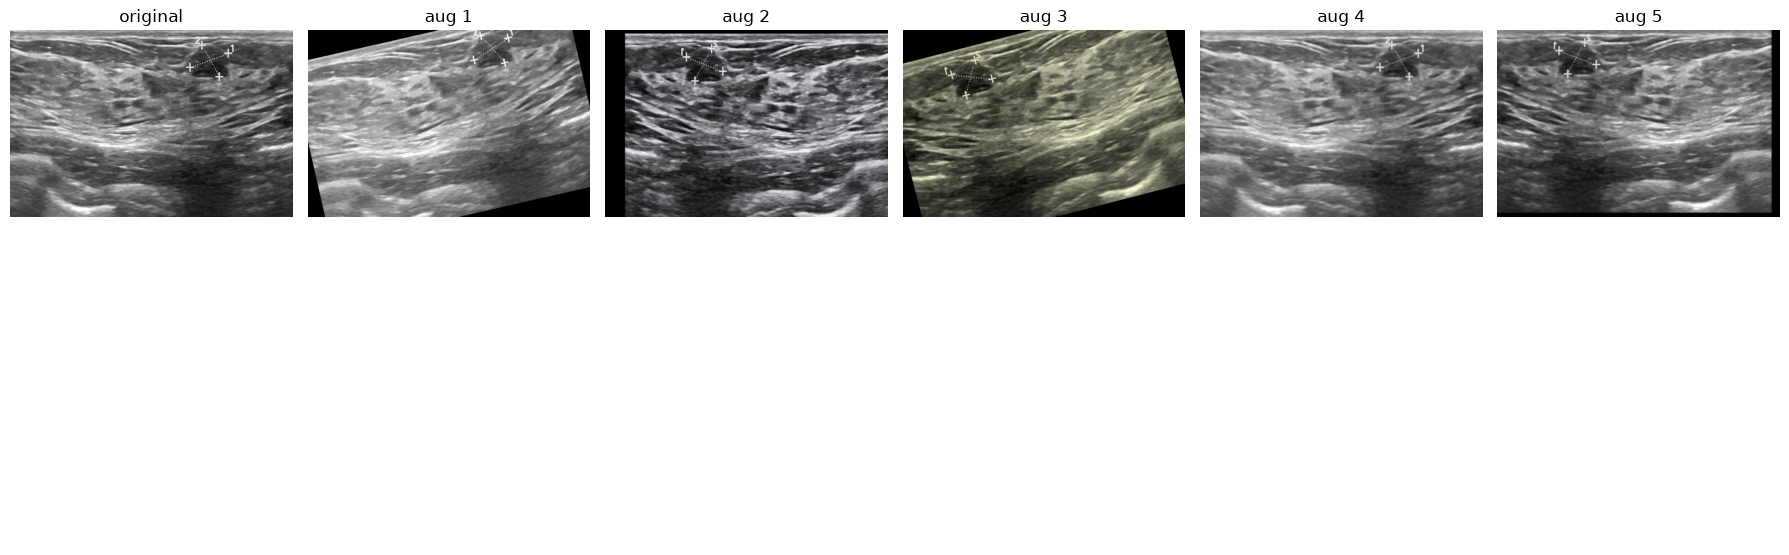

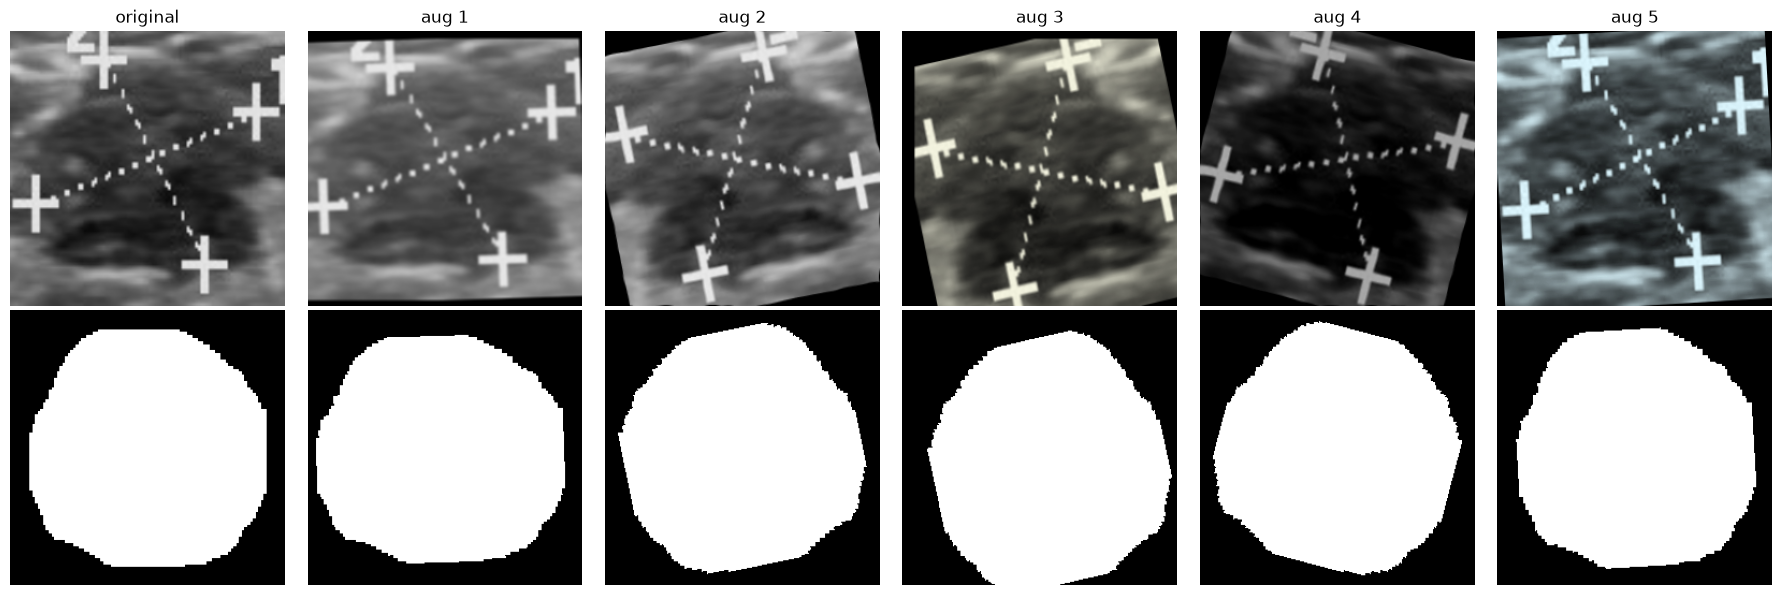

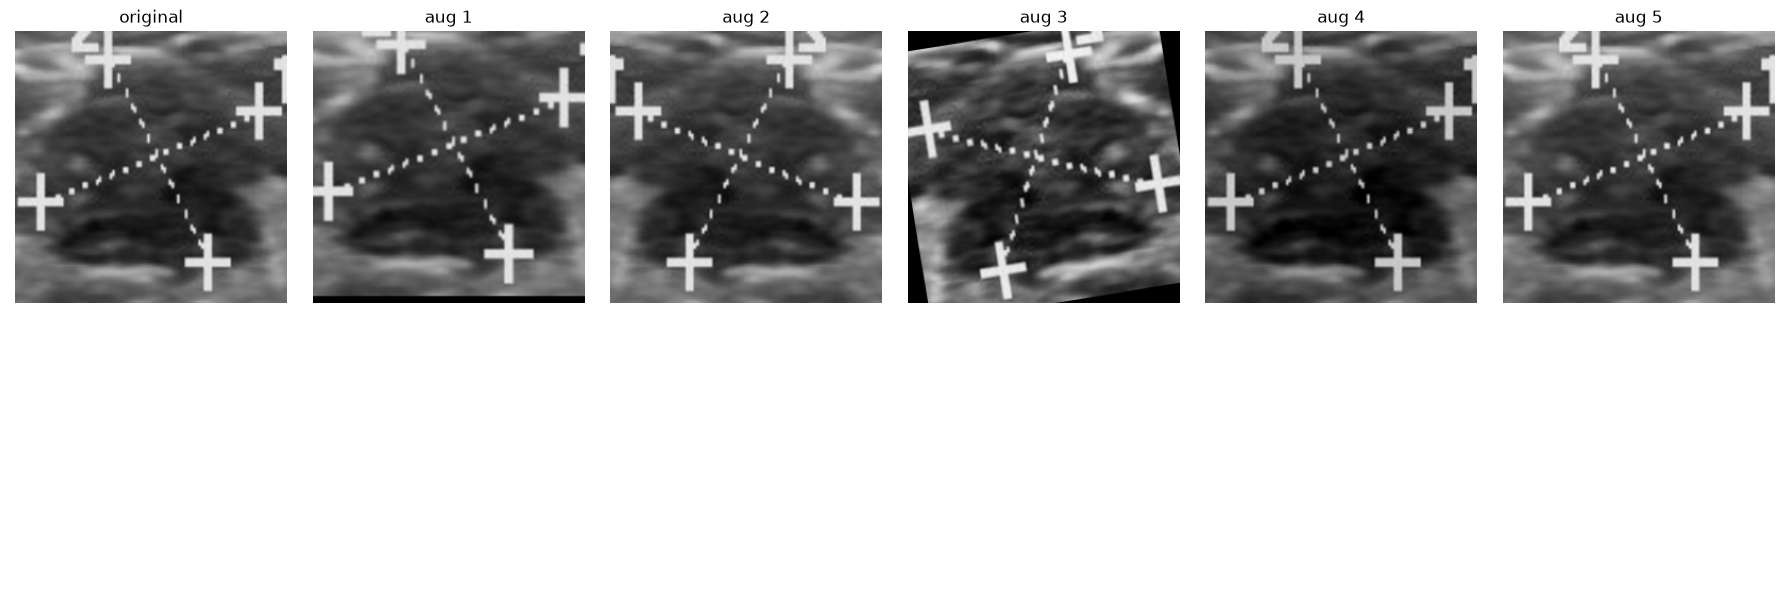

In [4]:
import random

import albumentations as A

from dataset.lesion_manifest import load_lesion_manifest
from preprocessing.mask_to_yolo import component_mask
from preprocessing.normalization import load_image_rgb
from preprocessing.roi_utils import crop_roi_pair
from preprocessing.augmentation import (
    build_yolo_augmentations,
    build_unet_augmentations,
    build_resnet_augmentations,
    visualize_augmentations,
)

train_lesions = load_lesion_manifest(REPO_ROOT / config["paths"]["splits_dir"] / "train_lesions.json")
sample_row = random.Random(config["seed"]).choice(train_lesions)
sample_image = load_image_rgb(sample_row["image_path"])
sample_mask = component_mask(sample_row["source_mask_path"], sample_row["component_label"])
roi_size = tuple(config["preprocessing"]["roi_size"])
roi_crop, mask_crop, _ = crop_roi_pair(
    sample_image, sample_mask, tuple(sample_row["bbox"]), pad_ratio=0.0, target_size=roi_size
)

# The YOLO pipeline is bbox-aware (BBoxSafeRandomCrop needs bboxes at call time),
# so the preview keeps bbox_params and feeds the sample lesion's pixel bbox through.
# Resize is dropped so the preview stays at the original resolution.
yolo_transforms = build_yolo_augmentations(config["yolo"]["imgsz"]).transforms
yolo_compose = A.Compose(
    [t for t in yolo_transforms if not isinstance(t, A.Resize)],
    bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"], min_visibility=0.3),
)


def yolo_preview(**kwargs):
    return yolo_compose(**kwargs, bboxes=[sample_row["bbox"]], class_labels=[0])


print("YOLO-stage augmentations (full safe + cautious set):")
visualize_augmentations(sample_image, yolo_preview, n_samples=5)

print("U-Net-stage augmentations (safe + cautious + tiny elastic):")
visualize_augmentations(roi_crop, build_unet_augmentations(roi_size), n_samples=5, mask=mask_crop)

print("ResNet-stage augmentations (conservative safe set only):")
visualize_augmentations(roi_crop, build_resnet_augmentations(roi_size), n_samples=5)


## Stage 2 — YOLO26n Detection

Builds the Ultralytics-format dataset (images + YOLO labels + `data.yaml`) from the Stage 1 split, then
trains YOLO26n to localize the tumor. The dataset-build cell is safe to run any time; **the training
cell trains a real model and should be run deliberately, not as part of "Run All".**

In [5]:
from dataset.splits import load_split
from yolo.dataset_builder import build_yolo_dataset

splits = {name: load_split(REPO_ROOT / config["paths"]["splits_dir"], name) for name in ("train", "val", "test")}
data_yaml = build_yolo_dataset(
    splits,
    REPO_ROOT / config["paths"]["yolo_dataset_dir"],
    min_area_px=config["preprocessing"]["min_mask_area_px"],
    bbox_pad_ratio=config["preprocessing"]["bbox_pad_ratio"],
)
print(f"YOLO dataset ready at {data_yaml}")


2026-10-07 11:23:44 | INFO     | yolo_dataset_builder | Built YOLO train split: 452 images -> /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/images/train
2026-10-07 11:23:44 | INFO     | yolo_dataset_builder | Built YOLO val split: 98 images -> /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/images/val
2026-10-07 11:23:44 | INFO     | yolo_dataset_builder | Built YOLO test split: 97 images -> /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/images/test
2026-10-07 11:23:44 | INFO     | yolo_dataset_builder | Wrote /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/data.yaml
YOLO dataset ready at /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/data.yaml


In [6]:
# TRAINING CELL — trains a real model. Run manually and deliberately, not via "Run All".
from yolo.train import train_yolo

train_yolo(config, data_yaml)


2026-10-07 11:23:45 | INFO     | yolo_train | Training YOLO26n on device=mps, data=/Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/data.yaml
New https://pypi.org/project/ultralytics/8.4.174 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.12.1 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, 

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=

In [7]:
# Evaluation — run after the training cell above has produced a checkpoint.
from yolo.evaluate import evaluate_yolo, compute_mean_iou

yolo_weights = REPO_ROOT / config["yolo"]["project"] / config["yolo"]["name"] / "weights" / "best.pt"
yolo_metrics = evaluate_yolo(yolo_weights, data_yaml, imgsz=config["yolo"]["imgsz"])

test_lesions = load_lesion_manifest(REPO_ROOT / config["paths"]["splits_dir"] / "test_lesions.json")
iou_metrics = compute_mean_iou(yolo_weights, test_lesions, imgsz=config["yolo"]["imgsz"])
print(yolo_metrics, iou_metrics)


Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.12.1 CPU (Apple M4)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1235.2±162.8 MB/s, size: 368.2 KB)
val: Scanning /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/labels/test.cache... 97 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 97/97 101.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.7s/it 11.6s2.3s
                   all         97        100      0.884       0.77      0.734      0.545
Speed: 0.4ms preprocess, 112.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/results/yolo/eval
2026-10-07 12:52:59 | INFO     | yolo_evaluate | YOLO test-split metrics: {'precision': 0.8838616700894374, 'recall':

## Stage 3 — U-Net Segmentation

Trains a U-Net (default: ResNet34 encoder, ImageNet-pretrained) on ROI crops derived from the
ground-truth lesion boxes. To compare architectures, reload `config` with one of the
`configs/unet_*.yaml` overrides (attention gates, EfficientNet-B0, U-Net++) before running the
training cell. **Trains a real model — run manually, not via "Run All".**

2026-10-07 12:53:02 | INFO     | unet_train | Training unet (encoder=resnet34) on device=mps


/Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


2026-10-07 12:54:03 | INFO     | unet_train | epoch 1/100 | train_loss=0.3767 train_dice=0.8296 | val_loss=0.2640 val_dice=0.9023
2026-10-07 12:54:04 | INFO     | unet_train | New best val dice 0.9023 -> saved checkpoints/unet/best_unet.pth
2026-10-07 12:55:00 | INFO     | unet_train | epoch 2/100 | train_loss=0.2424 train_dice=0.9097 | val_loss=0.2097 val_dice=0.9178
2026-10-07 12:55:01 | INFO     | unet_train | New best val dice 0.9178 -> saved checkpoints/unet/best_unet.pth
2026-10-07 12:55:57 | INFO     | unet_train | epoch 3/100 | train_loss=0.2069 train_dice=0.9180 | val_loss=0.1939 val_dice=0.9226
2026-10-07 12:55:57 | INFO     | unet_train | New best val dice 0.9226 -> saved checkpoints/unet/best_unet.pth
2026-10-07 12:56:53 | INFO     | unet_train | epoch 4/100 | train_loss=0.1861 train_dice=0.9236 | val_loss=0.1755 val_dice=0.9263
2026-10-07 12:56:53 | INFO     | unet_train | New best val dice 0.9263 -> saved checkpoints/unet/best_unet.pth
2026-10-07 12:57:49 | INFO     | une

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05,

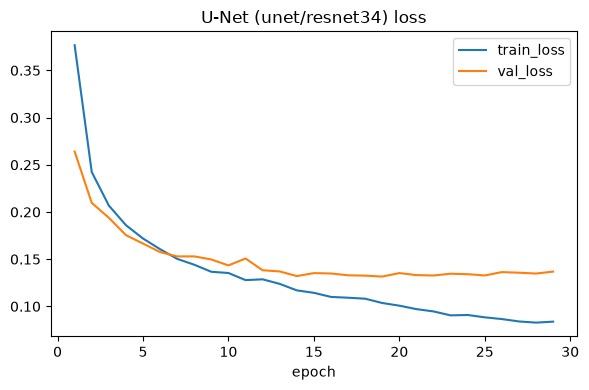

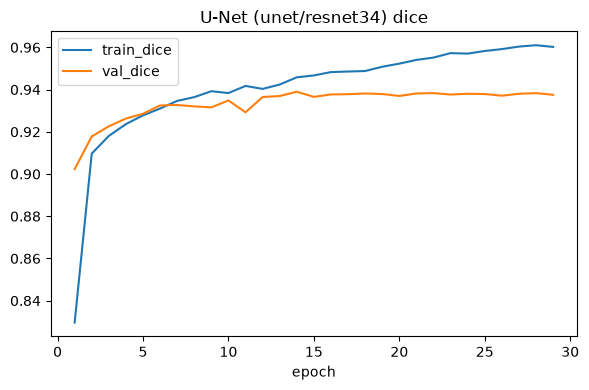

In [8]:
# TRAINING CELL — trains a real model. Run manually and deliberately, not via "Run All".
from unet.train import train_unet

train_unet(config)


2026-10-07 13:20:39 | INFO     | unet_evaluate | U-Net test-split metrics: {'dice': 0.9362252479559379, 'iou': 0.8822675563019391, 'precision': 0.9272990417655955, 'recall': 0.9485378711298721, 'specificity': 0.917760072117874}
{'dice': 0.9362252479559379, 'iou': 0.8822675563019391, 'precision': 0.9272990417655955, 'recall': 0.9485378711298721, 'specificity': 0.917760072117874}


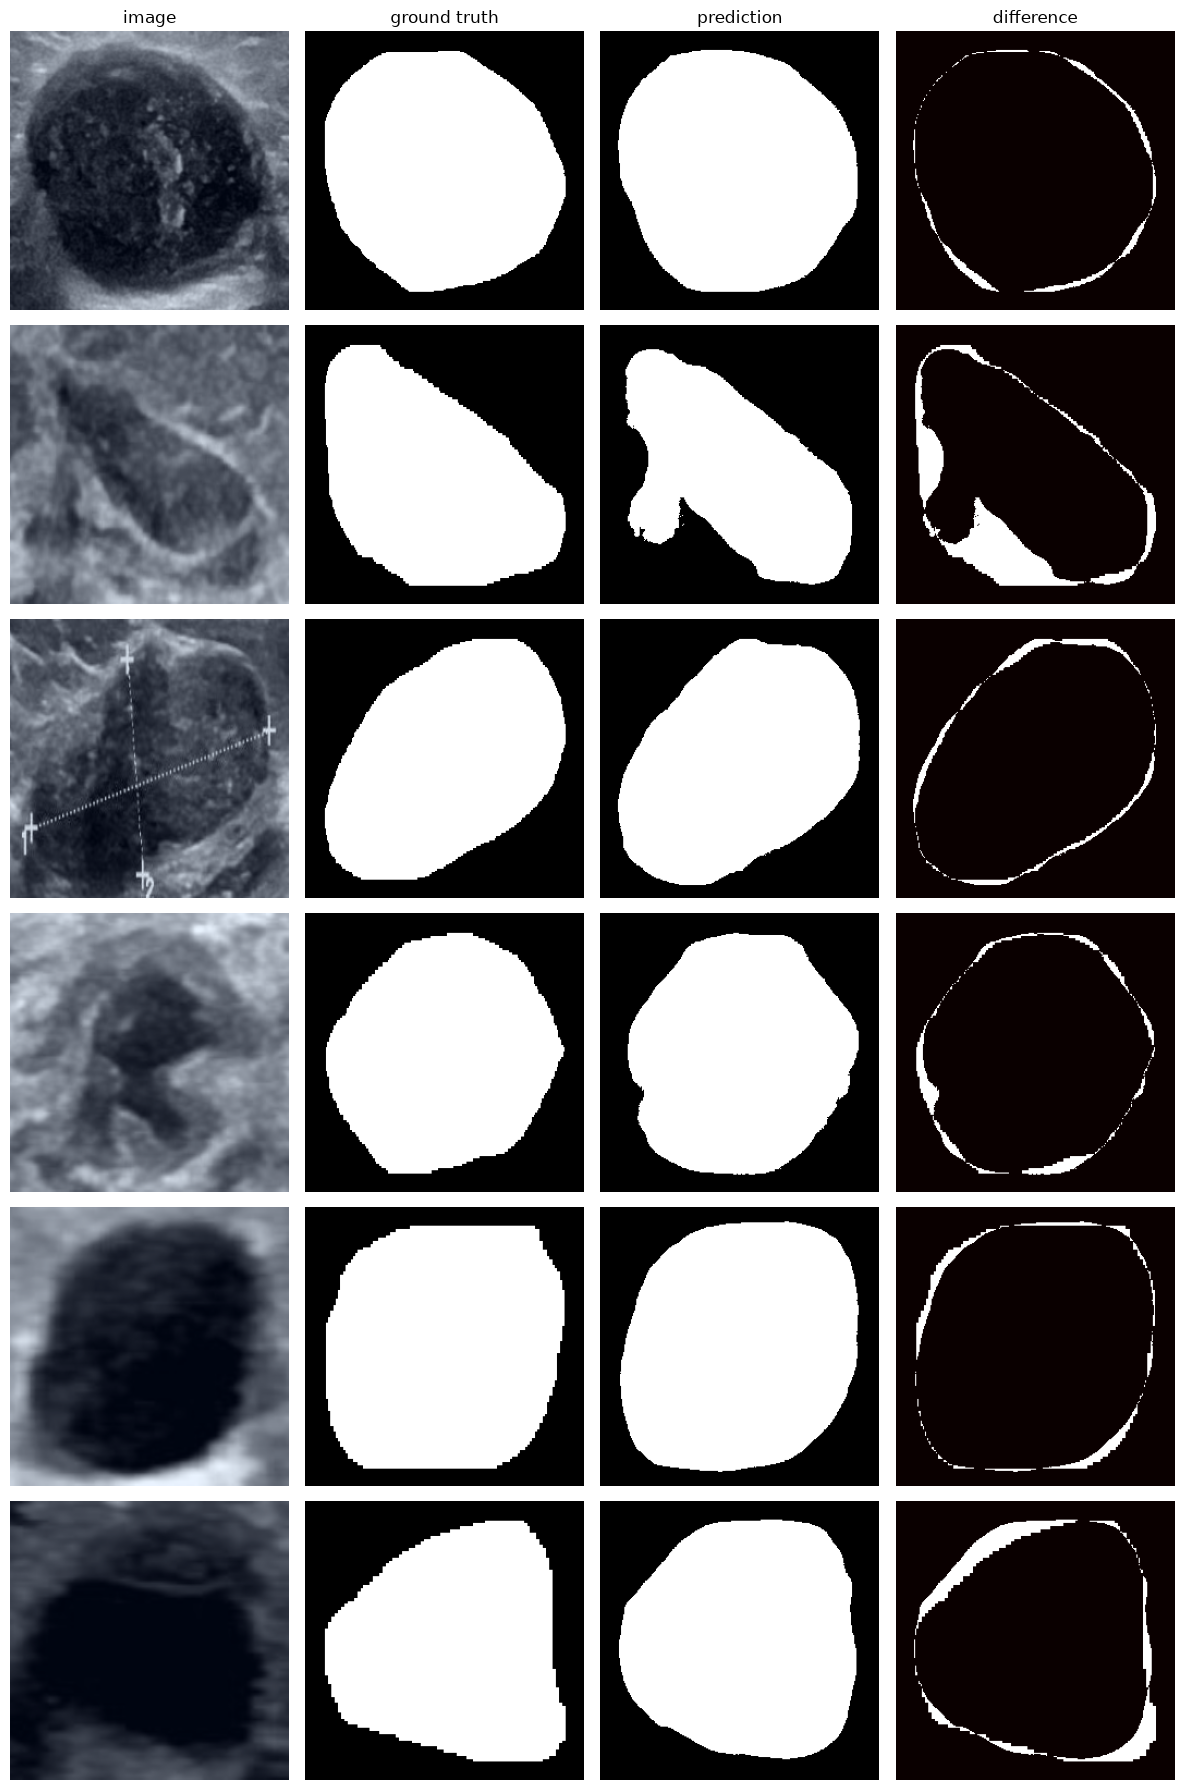

In [9]:
# Evaluation — run after the training cell above has produced a checkpoint.
from unet.evaluate import evaluate_unet

unet_checkpoint = REPO_ROOT / config["unet"]["checkpoint_dir"] / config["unet"]["checkpoint_name"]
unet_metrics = evaluate_unet(config, unet_checkpoint)
print(unet_metrics)


## Stage 4 — ResNet50 Classification

Two-phase transfer learning (linear-probe warmup, then full fine-tuning) on the masked tumor ROI,
using ground-truth lesion masks so this stage trains independently of Stage 3's own predictions.
**Trains a real model — run manually, not via "Run All".**

2026-10-07 13:21:01 | INFO     | resnet_train | Training ResNet50 on device=mps
2026-10-07 13:21:51 | INFO     | resnet_train | epoch 1/60 | train_loss=0.6545 train_acc=0.6540 | val_loss=0.6179 val_acc=0.6923
2026-10-07 13:21:51 | INFO     | resnet_train | New best val acc 0.6923 -> saved checkpoints/resnet/best_resnet.pth
2026-10-07 13:22:39 | INFO     | resnet_train | epoch 2/60 | train_loss=0.6019 train_acc=0.6875 | val_loss=0.5989 val_acc=0.6731
2026-10-07 13:23:26 | INFO     | resnet_train | epoch 3/60 | train_loss=0.5823 train_acc=0.6875 | val_loss=0.5841 val_acc=0.6731
2026-10-07 13:24:14 | INFO     | resnet_train | epoch 4/60 | train_loss=0.5587 train_acc=0.6875 | val_loss=0.5610 val_acc=0.6827
2026-10-07 13:25:02 | INFO     | resnet_train | epoch 5/60 | train_loss=0.5396 train_acc=0.7009 | val_loss=0.5384 val_acc=0.7212
2026-10-07 13:25:02 | INFO     | resnet_train | New best val acc 0.7212 -> saved checkpoints/resnet/best_resnet.pth
2026-10-07 13:25:02 | INFO     | resnet_tra

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

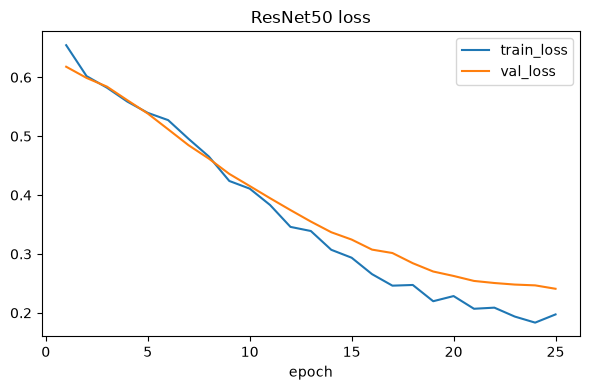

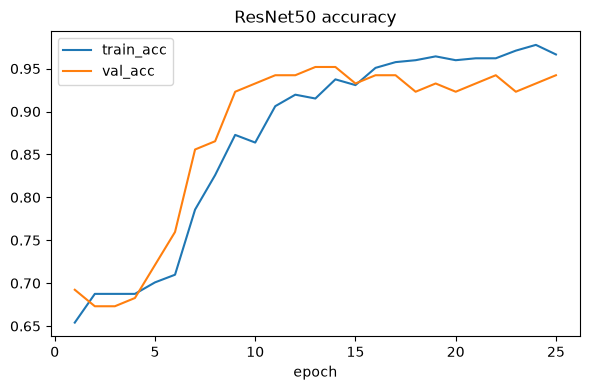

In [10]:
# TRAINING CELL — trains a real model. Run manually and deliberately, not via "Run All".
from resnet.train import train_resnet

train_resnet(config)


2026-10-07 13:44:21 | INFO     | resnet_evaluate | ResNet50 test-split metrics: {'accuracy': 0.93, 'precision': 0.9615384615384616, 'recall': 0.8064516129032258, 'f1': 0.8771929824561403, 'cohen_kappa': 0.8287671232876712, 'mcc': 0.8350365397224944, 'roc_auc': 0.9836372136512389, 'pr_auc': 0.9683242986696078}
{'accuracy': 0.93, 'precision': 0.9615384615384616, 'recall': 0.8064516129032258, 'f1': 0.8771929824561403, 'cohen_kappa': 0.8287671232876712, 'mcc': 0.8350365397224944, 'roc_auc': 0.9836372136512389, 'pr_auc': 0.9683242986696078}


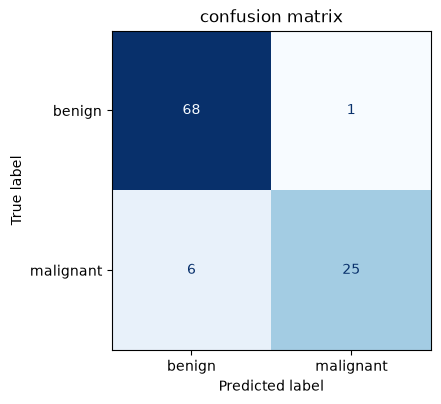

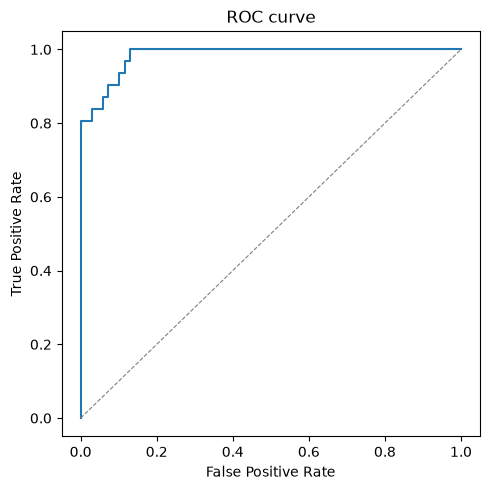

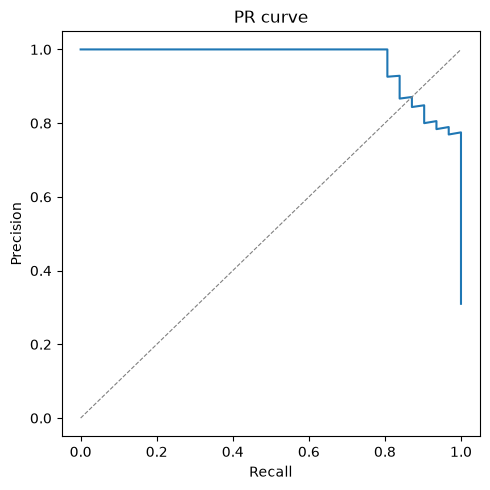

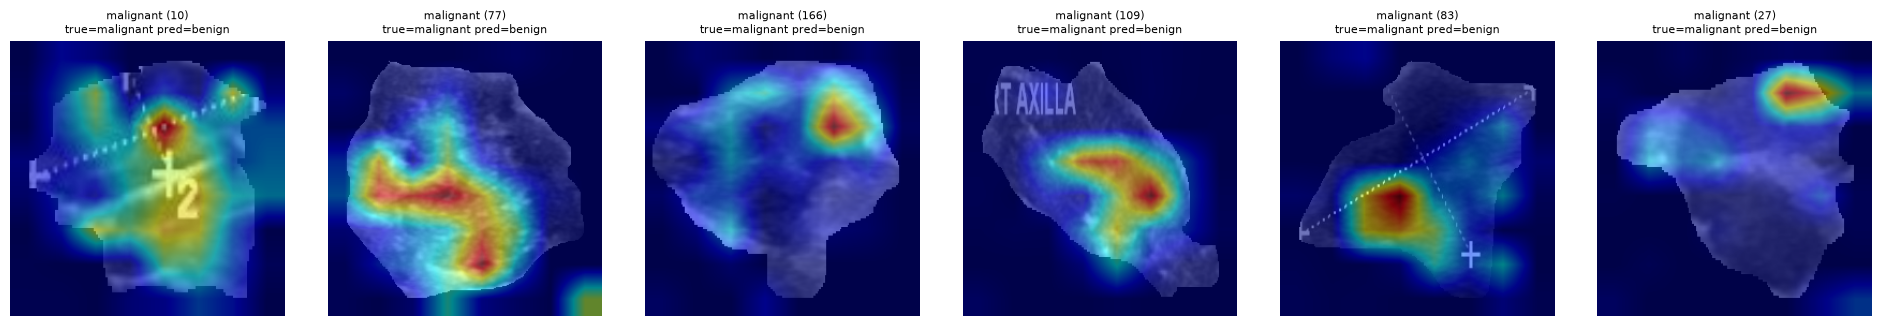

In [11]:
# Evaluation — run after the training cell above has produced a checkpoint.
from resnet.evaluate import evaluate_resnet

resnet_checkpoint = REPO_ROOT / config["resnet"]["checkpoint_dir"] / config["resnet"]["checkpoint_name"]
resnet_metrics = evaluate_resnet(config, resnet_checkpoint)
print(resnet_metrics)


## End-to-end cascade evaluation

Chains the *real* trained YOLO26n -> U-Net -> ResNet50 (not ground-truth-fed) over the test set, to
measure how much error propagates through the full cascade versus each stage's isolated evaluation
above. Requires all three checkpoints from Stages 2-4 to already exist.

In [12]:
from evaluation.cascade import evaluate_cascade

cascade_metrics = evaluate_cascade(config, split="test")
print(cascade_metrics)


2026-10-07 13:44:30 | INFO     | cascade_evaluate | End-to-end cascade metrics on test split: {'accuracy': 0.8295454545454546, 'precision': 0.6875, 'recall': 0.8148148148148148, 'f1': 0.7457627118644068, 'cohen_kappa': 0.6189376443418014, 'mcc': 0.6239919444536091, 'roc_auc': 0.8919247115968427, 'pr_auc': 0.7523922241347474, 'num_detection_failures': 9, 'mean_detection_iou': 0.6696470124503907, 'mean_segmentation_dice': 0.8068782813281391}
{'accuracy': 0.8295454545454546, 'precision': 0.6875, 'recall': 0.8148148148148148, 'f1': 0.7457627118644068, 'cohen_kappa': 0.6189376443418014, 'mcc': 0.6239919444536091, 'roc_auc': 0.8919247115968427, 'pr_auc': 0.7523922241347474, 'num_detection_failures': 9, 'mean_detection_iou': 0.6696470124503907, 'mean_segmentation_dice': 0.8068782813281391}


## Single-image inference demo

Runs the full cascade on one raw ultrasound image and visualizes every intermediate output
(detection, ROI, segmentation overlay, classification). Requires all three checkpoints to exist.

Predicted: benign (75.7%)


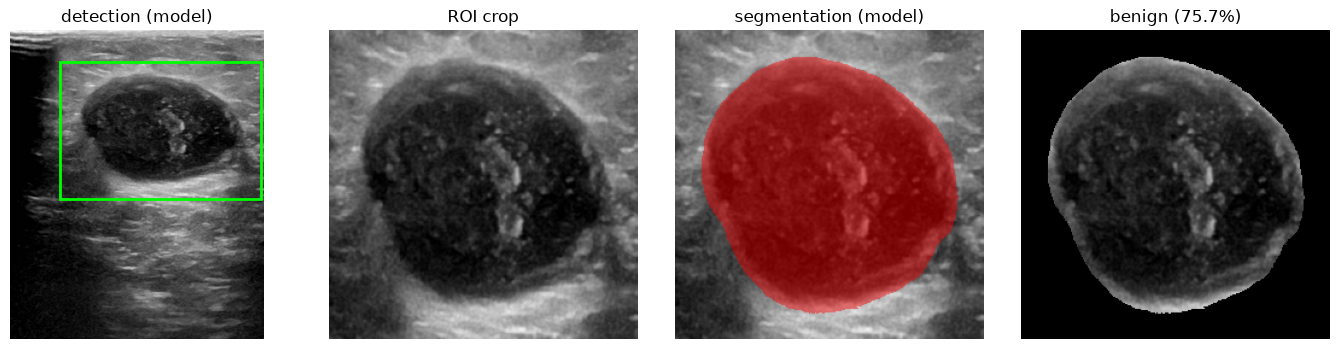

In [13]:
from inference.pipeline import build_pipeline
from inference.visualize import plot_case_result

test_rows = load_split(REPO_ROOT / config["paths"]["splits_dir"], "test")
sample_image_path = test_rows[0]["image_path"]

pipeline = build_pipeline(config)
case_result = pipeline.run(sample_image_path)
plot_case_result(case_result)
print(f"Predicted: {case_result.predicted_class} ({case_result.confidence:.1%})")


## Stage 5 — Clinician-in-the-loop demo

For interactive, physician-reviewed inference with accept/reject controls at every stage, run:

```bash
streamlit run app.py
```

The app reuses `inference/pipeline.py` and `preprocessing/roi_utils.py` — the same modules used above —
so its behavior matches this notebook's cascade exactly, with physician review layered on top.

## Stage 6 — Structured BI-RADS report (radiomics + RAG + LLM)

Drafts a structured breast-ultrasound report from the **clinician-approved** lesion mask, following the
ACR BI-RADS® Atlas 5th Edition ultrasound lexicon:

```
approved mask -> radiomic features -> BI-RADS lexicon descriptors -> rule-based category
             -> retrieval (BI-RADS knowledge chunks + 5 similar training cases) -> LLM draft -> schema validation
```

**Rules propose, LLM explains.** The BI-RADS category, likelihood-of-malignancy range and confidence come
from deterministic rules (`reporting/scoring.py`). The LLM only writes the rationale, recommendation and
patient summary, and the validator rejects any draft whose category disagrees, cites an unknown source, or
misstates a computed descriptor. The model never proposes category 6; only the clinician can set it.

All logic lives in `reporting/`; these cells only call into it, the same way `app.py` does.
Needs `pip install -r requirements-reporting.txt`.

**Model licence:** the default LLM, `Qwen/Qwen2.5-3B-Instruct`, is under the Qwen **Research** License
(non-commercial use only). Apache-2.0 alternatives: `Qwen/Qwen2.5-1.5B-Instruct` and
`Qwen/Qwen2.5-7B-Instruct` (set `reporting.llm.model_id` in `config.yaml`).

In [14]:
import reporting

report_cfg = config["reporting"]
missing = reporting.missing_dependencies(report_cfg["backend"])
print(f"Backend: {report_cfg['backend']} | LLM: {report_cfg['llm']['model_id']}")
print("Missing reporting dependencies:", missing or "none")

Backend: local | LLM: Qwen/Qwen2.5-3B-Instruct
Missing reporting dependencies: none


### 6a — Radiomic features and lexicon descriptors

Uses `case_result` from the single-image inference demo above. The model mask stands in for the
clinician-approved mask here; in the app it is whatever the clinician accepted or painted. Features are
computed after mapping the 256×256 ROI mask back to native image geometry, because the ROI resize distorts
the aspect ratio that orientation and shape depend on. Categories a single B-mode image can't assess
(vascularity, elasticity, skin, edema, special cases) are listed explicitly as *not assessable*.

In [15]:
import pandas as pd

from reporting.features import extract_features
from reporting.lexicon import map_to_lexicon

approved_mask = case_result.mask
features = extract_features(case_result.image, case_result.bbox, approved_mask)
descriptors = map_to_lexicon(features)

pd.DataFrame([
    {"category": d.category, "value": d.value, "assessable": d.assessable, "supports": d.polarity,
     "evidence": ", ".join(f"{k}={v}" for k, v in d.evidence.items())}
    for d in descriptors
])

,category,value,assessable,supports,evidence
0,Mass shape,oval,True,benign,"solidity=0.99, ellipse_fit_iou=0.953, axis_rat..."
1,Orientation,parallel,True,benign,"depth_to_width_ratio=0.684, major_axis_angle_d..."
2,Margin,circumscribed,True,benign,"spike_count=0.0, lobule_count=5.0, deep_concav..."
3,Echo pattern,hypoechoic,True,neutral,"echogenicity_ratio=0.361, anechoic_fraction=0...."
4,Posterior features,enhancement,True,neutral,"posterior_ratio=3.556, left_ratio=3.047, right..."
5,Calcifications,none identified,True,neutral,echogenic_foci_count=1.0
6,Vascularity (Doppler),not assessable,False,neutral,
7,Elasticity assessment,not assessable,False,neutral,
8,Skin changes,not assessable,False,neutral,
9,Edema,not assessable,False,neutral,


In [16]:
from reporting.scoring import assess

rules = assess(descriptors, features, case_result.class_probs["malignant"], mask_source="model")
print(f"Proposed BI-RADS {rules.category} | likelihood of malignancy {rules.likelihood} | score {rules.score}")
print(f"Confidence: {rules.confidence}", *(f"  - {r}" for r in rules.confidence_reasons), sep="\n")
pd.DataFrame(rules.points) if rules.points else "No suspicious points: every assessable descriptor is benign or neutral."

Proposed BI-RADS 3 | likelihood of malignancy >0% to ≤2% | score 0
Confidence: high


'No suspicious points: every assessable descriptor is benign or neutral.'

### 6b — Sanity-check the rules on the validation split

The lexicon thresholds were set from the training split's feature distributions. This cell runs
features -> lexicon -> rules on the **validation** split's ground-truth masks and tabulates the true labels
per proposed category, with and without the ResNet50 probability. This checks that the heuristics are
consistent; it is not a clinical validation. Takes about 30 s. Also writes `results/reporting/calibration_val.json`.

In [17]:
from reporting.calibration import run_calibration

calibration = run_calibration(config, split="val")
pd.concat(
    {mode: pd.DataFrame(calibration[mode]).T for mode in ("lexicon_only", "with_classifier")}, axis=1
).fillna(0).astype(int)

lexicon_only           with_classifier          
         benign malignant          benign malignant
2             5         0               5         0
3            34         0              34         0
4A           21         5              23         5
4B            9        20               7        11
4C            1         8               1        10
5             0         1               0         8

### 6c — Build the similar-case index

Embeds every **training** lesion (ground-truth mask, same ROI crop as Stage 4) with the trained ResNet50's
2048-d penultimate layer and stores the vectors, labels and thumbnails under `results/reporting/index/`.
Only the training split is indexed, so validation and test cases can never retrieve themselves. Run it once
after Stage 4 training; the app shows reports without similar cases if the index is missing.

In [18]:
from reporting.build_index import build_case_index

build_case_index(config)

indexed 461 training lesions -> results/reporting/index


PosixPath('results/reporting/index')

### 6d — Generate a draft report

**LLM CELL:** the first run downloads the model (about 6 GB for Qwen2.5-3B) and generation takes about a minute
on Apple-silicon MPS (much longer on CPU). Run it deliberately, not via "Run All". With
`reporting.backend: hf_api`, it calls the Hugging Face Inference API instead (needs `HF_TOKEN`).

If the model's output fails schema validation after the configured retries, `status` is `invalid` and no
draft text is shown. Only the computed evidence is returned.

In [19]:
from reporting.build_index import resnet_case_embedder
from reporting.service import build_report_service

report_service = build_report_service(
    config,
    hf_token=os.getenv("HF_TOKEN"),
    case_embedder=resnet_case_embedder(pipeline.resnet_model, pipeline.device),
)
report = report_service.generate(
    case_result, approved_mask, case_id=Path(sample_image_path).name, progress=lambda step: print(f"... {step}")
)
print(f"\nstatus={report.status} | BI-RADS {report.category} ({report.likelihood}) | confidence {report.confidence} "
      f"| attempts {report.attempts} | {sum(report.timings.values()):.1f}s")
if report.error:
    print("error:", report.error)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

... Extracting radiomic features
... Mapping to BI-RADS lexicon
... Retrieving knowledge and similar cases
... Drafting report
... Validating output

status=ok | BI-RADS 3 (>0% to ≤2%) | confidence high | attempts 1 | 53.4s


# Structured breast ultrasound report: benign (434).png

> AI-generated draft for clinician review. Not a diagnosis.

- **Review status:** pending_review
- **AI-proposed BI-RADS category:** 3 (likelihood of malignancy >0% to ≤2%)
- **Confidence:** high
- **Mask source:** model · **Box source:** model
- **Model:** Qwen/Qwen2.5-3B-Instruct (local) · prompt stage6-prompt-v1 · knowledge base kb-a84ab8584f
- **Generated:** 2026-10-07T11:45:07.522642+00:00

## BI-RADS lexicon descriptors

| Category | Value | Assessable | Supports | Measurements |
|---|---|---|---|---|
| Mass shape | oval | yes | benign | solidity=0.99, ellipse_fit_iou=0.953, axis_ratio=0.678, circularity=0.836 |
| Orientation | parallel | yes | benign | depth_to_width_ratio=0.684, major_axis_angle_deg=6.6 |
| Margin | circumscribed | yes | benign | spike_count=0.0, lobule_count=5.0, deep_concavities=0.0, boundary_roughness=0.022, boundary_cnr=1.124 |
| Echo pattern | hypoechoic | yes | neutral | echogenicity_ratio=0.361, anechoic_fraction=0.359, solid_fraction=0.234, local_heterogeneity=0.219 |
| Posterior features | enhancement | yes | neutral | posterior_ratio=3.556, left_ratio=3.047, right_ratio=4.065, available_fraction=1.0 |
| Calcifications | none identified | yes | neutral | echogenic_foci_count=1.0 |
| Vascularity (Doppler) | not assessable | no | neutral |  |
| Elasticity assessment | not assessable | no | neutral |  |
| Skin changes | not assessable | no | neutral |  |
| Edema | not assessable | no | neutral |  |
| Special cases | not assessable | no | neutral |  |

## Rationale

| Descriptor | Value | Supports | Source |
|---|---|---|---|
| Mass shape | oval | benign | feature:shape |
| Orientation | parallel | benign | feature:orientation |
| Margin | circumscribed | benign | feature:margin |
| Echo pattern | hypoechoic | neutral | feature:echo_pattern |
| Posterior features | enhancement | neutral | feature:posterior |

## Recommendation

Probably benign: short-interval follow-up ultrasound in 6 months (or continued surveillance).

## Limitations

- Automated analysis of a single B-mode still image; real-time scanning, Doppler, elastography, prior imaging and clinical history were not available.
- Lexicon thresholds are heuristics calibrated on the BUSI training set, not validated clinical cut-offs.
- Not assessable here: Vascularity (Doppler), Elasticity assessment, Skin changes, Edema, Special cases.
- Orientation: Assumes the image's top edge is the skin surface (standard probe orientation).
- Echo pattern: Echogenicity is relative to the surrounding tissue ring, not to subcutaneous fat.
- Calcifications: Limited reliability: speckle can mimic foci. Correlate with mammography.

## Evidence

- `kb:us-shape-oval`: Mass shape: oval
- `kb:us-orientation-parallel`: Orientation: parallel
- `kb:us-margin-circumscribed`: Margin: circumscribed
- `kb:us-echo-hypoechoic`: Echo pattern: hypoechoic
- `kb:us-posterior-enhancement`: Posterior features: enhancement
- `kb:us-calcifications`: Calcifications on ultrasound
- `kb:cat-3`: Category 3: Probably benign
- `kb:us-not-assessable-bmode`: Features not assessable from a single B-mode image
- `kb:us-suspicious-features`: Suspicious ultrasound features
- `kb:us-posterior-none`: Posterior features: none
- `kb:us-echo-complex`: Echo pattern: complex cystic and solid
- similar case `benign (262)#1`: benign (similarity 0.68)
- similar case `benign (370)#1`: benign (similarity 0.68)
- similar case `benign (403)#1`: benign (similarity 0.65)
- similar case `benign (354)#1`: benign (similarity 0.63)
- similar case `benign (405)#1`: benign (similarity 0.62)


benign (262)#1: benign (similarity 0.68)


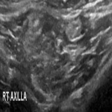

benign (370)#1: benign (similarity 0.68)


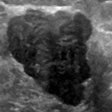

benign (403)#1: benign (similarity 0.65)


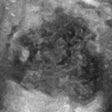

benign (354)#1: benign (similarity 0.63)


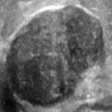

benign (405)#1: benign (similarity 0.62)


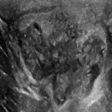

In [20]:
from IPython.display import Image as IPImage, Markdown, display

from reporting.export import report_to_markdown

# review=None renders the draft as "pending_review"; the patient summary is shown only after a clinician accepts.
display(Markdown(report_to_markdown(report.to_dict(), review=None, stale=False)))
for case in report.similar_cases:
    print(f"{case['id']}: {case['label']} (similarity {case['similarity']:.2f})")
    display(IPImage(filename=case["thumbnail"], width=112))

In [21]:
# What the clinician sees only after "Accept report" in the app (locked until then).
print(report.patient_summary)

This ultrasound looked at a small area with an oval shape, parallel orientation, and a well-defined, smooth edge. Your doctor will review the images with you and check again in a few months to make sure everything looks normal.


In the app (`streamlit run app.py`), Stage 6 appears after classification. Click **Generate draft
report**, then review the Features, Evidence, Draft report and Patient summary tabs, and **Accept**, **Edit and
accept** (including setting category 6) or **Reject**. Every action is written to
`results/inference/audit_log.jsonl`. Changing the box or mask afterwards marks the report stale and requires
regeneration.